# PyPSA-DE Network Analysis


In [1]:
import os
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
import warnings, yaml, pathlib
from matplotlib import cm

# ── Fix GDAL/cartopy data path ──────────────────────────────
import cartopy
gdal_data = os.path.join(os.path.dirname(cartopy.__file__), "data")
if os.path.exists(gdal_data):
    os.environ["GDAL_DATA"] = gdal_data

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
%matplotlib inline

Cannot find header.dxf (GDAL_DATA is not defined)


## 0 — Configuration
Set the run name, scenario, planning horizon, and paths.  
Adjust `YEAR` to inspect different investment periods.

In [17]:
# ── User settings ──────────────────────────────────────────────
RUN_PREFIX = "20260611_base_run2_6H"  #20260611_base_run2_6H
SCENARIO   = "KN2045_Mix"
CLUSTERS   = 27
YEAR       = 2035                      # planning horizon to analyse

ROOT = pathlib.Path(r"e:\23-06-13_localCode\FiBe\pypsa-de")
NET_DIR = ROOT / "results" / RUN_PREFIX / SCENARIO / "networks"
NET_FILE = NET_DIR / f"base_s_{CLUSTERS}__none_{YEAR}.nc"

# Load plotting config for consistent colours
with open(ROOT / "config" / "plotting.default.yaml") as f:
    plot_cfg = yaml.safe_load(f)["plotting"]
with open(ROOT / "config" / "config.de.yaml") as f:
    de_cfg = yaml.safe_load(f)
tech_colors = {**plot_cfg.get("tech_colors", {}), **de_cfg.get("plotting", {}).get("tech_colors", {})}

print(f"Network file: {NET_FILE}")
print(f"Exists: {NET_FILE.exists()}")

Network file: e:\23-06-13_localCode\FiBe\pypsa-de\results\20260611_base_run2_6H\KN2045_Mix\networks\base_s_27__none_2035.nc
Exists: True


In [18]:
# ── Load network & build German subsets ────────────────────────
n = pypsa.Network(str(NET_FILE))

# German AC buses & derived component masks
de_buses = n.buses.query("country == 'DE' and carrier == 'AC'").index
de_all_buses = n.buses.query("country == 'DE'").index

de_gens  = n.generators[n.generators.bus.isin(de_buses)].index
de_loads = n.loads[n.loads.bus.isin(de_all_buses)].index
de_stores = n.stores[n.stores.bus.isin(de_all_buses)].index
de_links = n.links[n.links.bus0.isin(de_all_buses) | n.links.bus1.isin(de_all_buses)].index
de_sus   = n.storage_units[n.storage_units.bus.isin(de_buses)].index

# Snapshot weighting (for correct energy sums with temporal aggregation)
sw = n.snapshot_weightings.generators

print(f"Loaded {SCENARIO} / {YEAR}  —  {len(n.buses)} buses, "
      f"{len(de_buses)} DE AC buses, {len(n.snapshots)} snapshots")

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            ('9', 6),
            ('9', 7)],
           length=352) for attribute mu_neg of Line are not in main components dataframe lines
            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            

Loaded KN2045_Mix / 2035  —  777 buses, 8 DE AC buses, 1460 snapshots


## 1 — Network Topology Map
All AC buses, lines, and DC links on a map of Germany.

e:\23-06-13_localCode\FiBe\pypsa-de\.pixi\envs\default\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning:

Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.



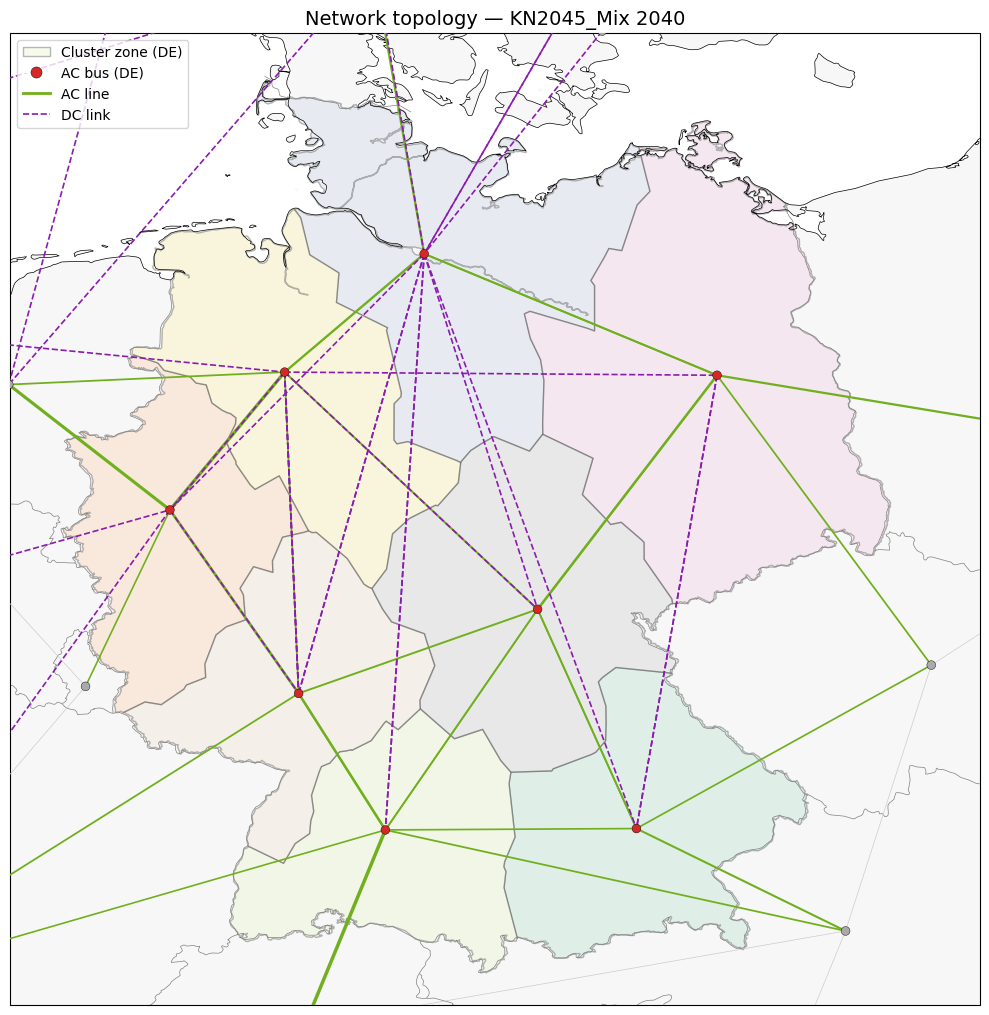

In [4]:
import geopandas as gpd

proj = ccrs.EqualEarth()
DE_BOUNDS = [5.5, 15.5, 47.0, 55.5]  # lon_min, lon_max, lat_min, lat_max

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# ── DE cluster regions (Voronoi zones) ────────────────────────
regions = gpd.read_file(ROOT / "resources" / f"regions_onshore_base_s_{CLUSTERS}.geojson")
de_regions = regions[regions.name.isin(de_buses)]
# Light transparent fill + solid outline per cluster
cluster_cmap = plt.cm.Pastel2
for i, (_, row) in enumerate(de_regions.iterrows()):
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cluster_cmap(i / max(len(de_regions) - 1, 1)),
        edgecolor="#333333", linewidth=1.0, alpha=0.35, zorder=1,
    )

# AC buses
ac_buses = n.buses[n.buses.carrier == "AC"]
ax.scatter(
    ac_buses.x, ac_buses.y,
    transform=ccrs.PlateCarree(), s=40, zorder=5,
    c=["#d62728" if b in de_buses else "#aaaaaa" for b in ac_buses.index],
    edgecolors="k", linewidths=0.3,
)

# AC lines
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    is_de = ln.bus0 in de_buses or ln.bus1 in de_buses
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(),
        color="#70af1d" if is_de else "#cccccc",
        linewidth=1.0 + 1.5 * (ln.s_nom_opt / n.lines.s_nom_opt.max()) if is_de else 0.5,
        zorder=3,
    )

# DC links (exclude "-reversed" duplicates so each corridor is drawn once)
dc_links = n.links[
    (n.links.carrier == "DC") & ~n.links.index.str.endswith("-reversed")
]
for _, lk in dc_links.iterrows():
    b0, b1 = n.buses.loc[lk.bus0], n.buses.loc[lk.bus1]
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(), color="#8a1caf",
        linewidth=1.2, linestyle="--", zorder=4,
    )

# Legend with proxy artists
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cluster_cmap(0.5), edgecolor="#333333", linewidth=1.0, alpha=0.35, label="Cluster zone (DE)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markeredgecolor="k", markeredgewidth=0.3, markersize=8, label="AC bus (DE)"),
    Line2D([0], [0], color="#70af1d", linewidth=2.0, label="AC line"),
    Line2D([0], [0], color="#8a1caf", linewidth=1.2, linestyle="--", label="DC link"),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title(f"Network topology — {SCENARIO} {YEAR}", fontsize=14)
plt.tight_layout()
plt.show()

## 2 — Battery Storage & Generation / Demand Pie Map
Each German cluster is coloured by installed battery storage capacity.  
Two-sided pie charts show total electricity **generation** (left) vs **demand** (right).

In [52]:
# ── Prepare per-cluster data ───────────────────────────────────
# Helper: map any bus back to its AC parent via n.buses.location
def to_ac_bus(bus_name):
    if "location" in n.buses.columns and bus_name in n.buses.index:
        loc = n.buses.loc[bus_name, "location"]
        if pd.notna(loc):
            return loc
    return bus_name

# ── Stationary BESS (carrier == "battery", NOT EV/home) ──────
bess_stores = n.stores[
    (n.stores.carrier == "battery")
    & (n.stores.bus.isin(de_all_buses))
].copy()
bess_stores["ac_bus"] = bess_stores.bus.map(to_ac_bus)
bess_cap_per_bus = bess_stores.groupby("ac_bus")["e_nom_opt"].sum() / 1e3  # GWh

# EV batteries (separate, for context)
ev_stores = n.stores[
    (n.stores.carrier == "EV battery")
    & (n.stores.bus.isin(de_all_buses))
]

# Battery charge / discharge power capacity (via links)
batt_ch = n.links[(n.links.carrier == "battery charger") & (n.links.bus0.isin(de_buses))]
batt_dis = n.links[(n.links.carrier == "battery discharger") & (n.links.bus1.isin(de_buses))]
batt_charge_cap = batt_ch["p_nom_opt"].sum() / 1e3   # GW
batt_discharge_cap = batt_dis["p_nom_opt"].sum() / 1e3

# For the map plot: use BESS + home combined for the colour scale
batt_stores_all = n.stores[
    (n.stores.carrier.isin(["battery", "home battery"]))
    & (n.stores.bus.isin(de_all_buses))
].copy()
batt_stores_all["ac_bus"] = batt_stores_all.bus.map(to_ac_bus)
batt_cap_per_bus = batt_stores_all.groupby("ac_bus")["e_nom_opt"].sum() / 1e3  # GWh

# ── Generation per DE AC bus ──────────────────────────────────
# a) Generators (VRE, hydro RoR, etc.)
gen_p = (n.generators_t.p[de_gens].multiply(sw, axis=0)).sum()  # MWh
vre_gen_per_bus = gen_p.groupby(n.generators.loc[de_gens, "bus"]).sum() / 1e6  # TWh

# b) Link-based dispatchable generation injecting into DE AC buses
#    (gas CHPs, CCGTs, H2 fuel cells, etc. — modelled as links, not generators)
_link_gen_excl = {"DC", "battery charger", "battery discharger",
                  "home battery charger", "home battery discharger",
                  "electricity distribution grid"}
link_gen_links = n.links[
    (n.links.bus1.isin(de_buses))
    & ~n.links.carrier.isin(_link_gen_excl)
    & ~n.links.index.str.endswith("-reversed")
]
link_gen_e = -(n.links_t.p1[link_gen_links.index].multiply(sw, axis=0)).sum()  # −p1 = delivery
link_gen_per_bus = link_gen_e.groupby(
    n.links.loc[link_gen_links.index, "bus1"]
).sum() / 1e6  # TWh

# c) Combined total generation per bus
gen_per_bus = vre_gen_per_bus.add(link_gen_per_bus, fill_value=0)

# ── Demand: electricity loads are on low-voltage buses ────────
de_lv_buses = n.buses[(n.buses.country == "DE") & (n.buses.carrier == "low voltage")].index
elec_loads = n.loads[
    (n.loads.bus.isin(de_lv_buses)) & (n.loads.carrier == "electricity")
]
load_p = (n.loads_t.p_set[elec_loads.index].multiply(sw, axis=0)).sum()
# Map LV bus → AC bus for spatial aggregation
elec_loads_ac = elec_loads.bus.map(to_ac_bus)
load_per_bus = load_p.groupby(elec_loads_ac).sum() / 1e6  # TWh

# ── Home batteries (on low-voltage bus) ───────────────────────
home_batt_stores = n.stores[
    (n.stores.carrier == "home battery")
    & (n.stores.bus.isin(de_all_buses))
]
home_batt_ch = n.links[(n.links.carrier == "home battery charger") & (n.links.bus0.isin(de_lv_buses))]
home_batt_dis = n.links[(n.links.carrier == "home battery discharger") & (n.links.bus1.isin(de_lv_buses))]

# ── Net electricity consumption per bus (incl. sector coupling) ────
# Sum all withdrawals from DE AC buses: links + loads.
# Includes heat pumps, electrolysis, EV charging (via LV distribution), etc.
# Excludes round-trip storage (BESS, home battery, PHS) whose energy returns to the grid.

# a) Links withdrawing from AC buses (bus0 on AC, excl. DC & reversed)
# Exclude round-trip storage chargers (energy returns to grid via discharger)
round_trip_carriers = {"battery charger", "home battery charger"}
ac_consuming_links = n.links[
    (n.links.bus0.isin(de_buses))
    & (n.links.carrier != "DC")
    & ~n.links.carrier.isin(round_trip_carriers)
    & ~n.links.index.str.endswith("-reversed")
]
link_withdrawal = (
    n.links_t.p0[ac_consuming_links.index]
    .clip(lower=0).multiply(sw, axis=0)
).sum()
link_withdrawal_per_bus = link_withdrawal.groupby(
    n.links.loc[ac_consuming_links.index, "bus0"]
).sum() / 1e6  # TWh

# b) Loads directly on AC buses (if any)
ac_direct_loads = n.loads[n.loads.bus.isin(de_buses)]
if len(ac_direct_loads):
    ac_load_e = (n.loads_t.p_set[ac_direct_loads.index].multiply(sw, axis=0)).sum()
    ac_load_per_bus = ac_load_e.groupby(n.loads.loc[ac_direct_loads.index, "bus"]).sum() / 1e6
# c) Storage-unit charging (PHS) excluded — round-trip storage returns to grid

# Combine into net electricity consumption per AC bus
# (excl. BESS & PHS charging which discharge back to grid;
#  incl. EV charging via LV distribution, heat pumps, electrolysis, etc.)
total_elec_per_bus = link_withdrawal_per_bus.copy()
if len(ac_direct_loads):
    total_elec_per_bus = total_elec_per_bus.add(ac_load_per_bus, fill_value=0)

# ── Summary ──────────────────────────────────────────────────
W = 63

def _p(s):
    print(f"║{s:<{W}}║")

def _hdr():
    _p(f"  {'':24s}{'Existing':>10s}  {'Expansion':>10s}  {'Total':>10s} ")

def _row(label, exist, total):
    expan = total - exist
    _p(f"    {label:22s}{exist:10.3f}  {expan:10.3f}  {total:10.3f} ")

print("╔" + "═" * W + "╗")
print(f"║{f'Battery Storage Summary — DE {YEAR}':^{W}}║")
print("╠" + "═" * W + "╣")

_p(" 1) Grid-scale BESS (AC bus)")
_hdr()
_row("Energy [GWh]",   bess_stores.e_nom.sum()/1e3,       bess_stores.e_nom_opt.sum()/1e3)
_row("Charge [GW]",    batt_ch.p_nom.sum()/1e3,            batt_charge_cap)
_row("Discharge [GW]", batt_dis.p_nom.sum()/1e3,           batt_discharge_cap)
_p("")
_p(" 2) Home batteries (LV bus)")
_hdr()
_row("Energy [GWh]",   home_batt_stores.e_nom.sum()/1e3,   home_batt_stores.e_nom_opt.sum()/1e3)
_row("Charge [GW]",    home_batt_ch.p_nom.sum()/1e3,       home_batt_ch.p_nom_opt.sum()/1e3)
_row("Discharge [GW]", home_batt_dis.p_nom.sum()/1e3,      home_batt_dis.p_nom_opt.sum()/1e3)
_p("")
_p(" 3) EV batteries (LV bus, exogenous)")
_hdr()
_row("Energy [GWh]",   ev_stores.e_nom.sum()/1e3,          ev_stores.e_nom_opt.sum()/1e3)

print("╠" + "═" * W + "╣")
_p(f"  VRE + hydro gen.:     {vre_gen_per_bus.sum():>30.1f} TWh")
_p(f"  Dispatchable gen.:    {link_gen_per_bus.sum():>30.1f} TWh")
_p(f"    (CHPs, CCGTs, H2 turbines, etc.)")
_p(f"  Total DE generation:  {gen_per_bus.sum():>30.1f} TWh")
_p(f"  Direct elec demand:   {load_per_bus.sum():>30.1f} TWh")
_p(f"  Net elec consump.:    {total_elec_per_bus.sum():>30.1f} TWh")
_p(f"    (excl. BESS/PHS round-trip; incl. HP, H2, EV, etc.)")
print("╚" + "═" * W + "╝")

╔═══════════════════════════════════════════════════════════════╗
║               Battery Storage Summary — DE 2035               ║
╠═══════════════════════════════════════════════════════════════╣
║ 1) Grid-scale BESS (AC bus)                                   ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]               0.100     165.791     165.891   ║
║    Charge [GW]                0.000      14.111      14.111   ║
║    Discharge [GW]             0.000      14.402      14.402   ║
║                                                               ║
║ 2) Home batteries (LV bus)                                    ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]               2.832      29.307      32.140   ║
║    Charge [GW]                0.096       2.650       2.746   ║
║    Discharge [GW]             0.098       2.704       2.803   ║
║                                                               ║
║ 3) EV ba

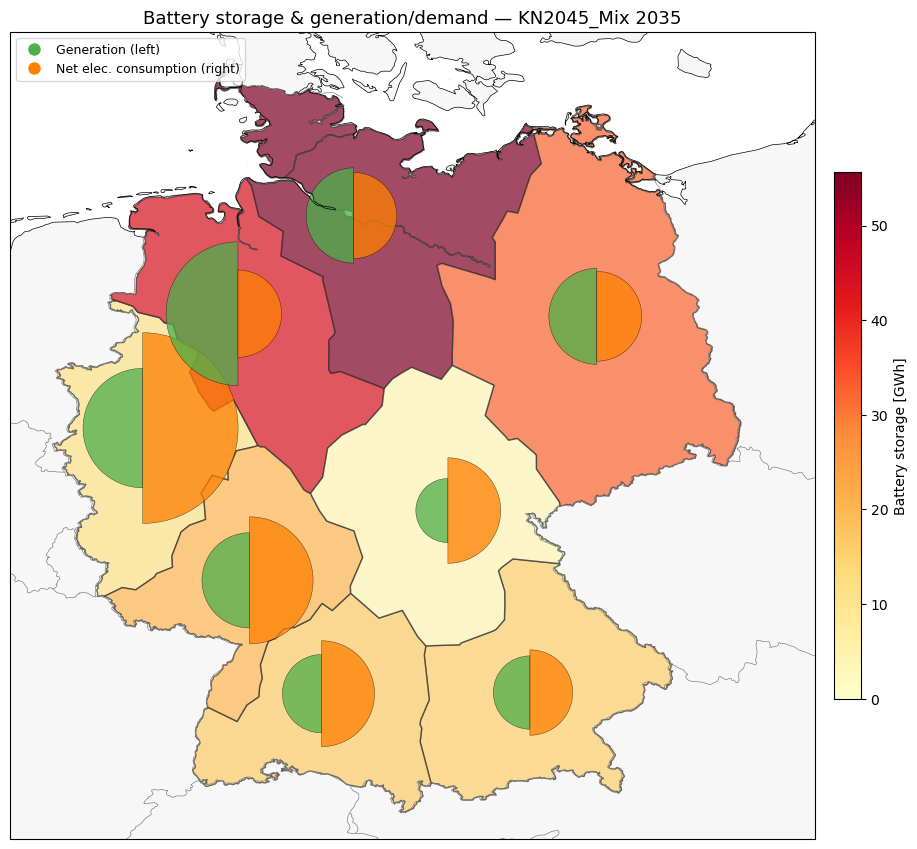

In [54]:
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

# ── Fill DE cluster zones with BESS heatmap ───────────────────
batt_vals = batt_cap_per_bus.reindex(de_buses, fill_value=0)  #dont include EV batteries, see previous cell
vmax = max(batt_vals.max(), 0.01)
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.YlOrRd

for _, row in de_regions.iterrows():
    bus = row["name"]
    val = batt_vals.get(bus, 0)
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap(norm(val)),
        edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label("Battery storage [GWh]")

# ── Two-sided pie charts (generation left, net consumption right) ──
PIE_SCALE = 0.75  # visual radius scaling factor
# demand_per_bus = load_per_bus          # direct electricity demand only
demand_per_bus = total_elec_per_bus      # net (excl. BESS/PHS round-trip)
max_val = max(gen_per_bus.max(), demand_per_bus.max(), 0.01)

for bus in de_buses:
    bx, by = proj.transform_point(
        ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree()
    )
    g = gen_per_bus.get(bus, 0)
    d = demand_per_bus.get(bus, 0)
    r = PIE_SCALE * np.sqrt(max(g, d) / max_val) * 1e5  # radius in map units
    if r < 1e3:
        continue
    # Left half = generation (green), right half = net consumption (orange)
    w_gen  = Wedge((bx, by), r, 90, 270, facecolor="#4daf4a", edgecolor="k", linewidth=0.3, alpha=0.75)
    w_load = Wedge((bx, by), r * np.sqrt(d / max(g, 1e-9)), 270, 90,
                   facecolor="#ff7f00", edgecolor="k", linewidth=0.3, alpha=0.75)
    ax.add_patch(w_gen)
    ax.add_patch(w_load)

# Legend proxy
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4daf4a", markersize=10, label="Generation (left)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f00", markersize=10, label="Net elec. consumption (right)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title(f"Battery storage & generation/demand — {SCENARIO} {YEAR}", fontsize=13)
plt.tight_layout()
plt.show()

## 3 — Mean Electricity Price Map
Mean marginal price (€/MWh) at each German AC bus, written on the map.

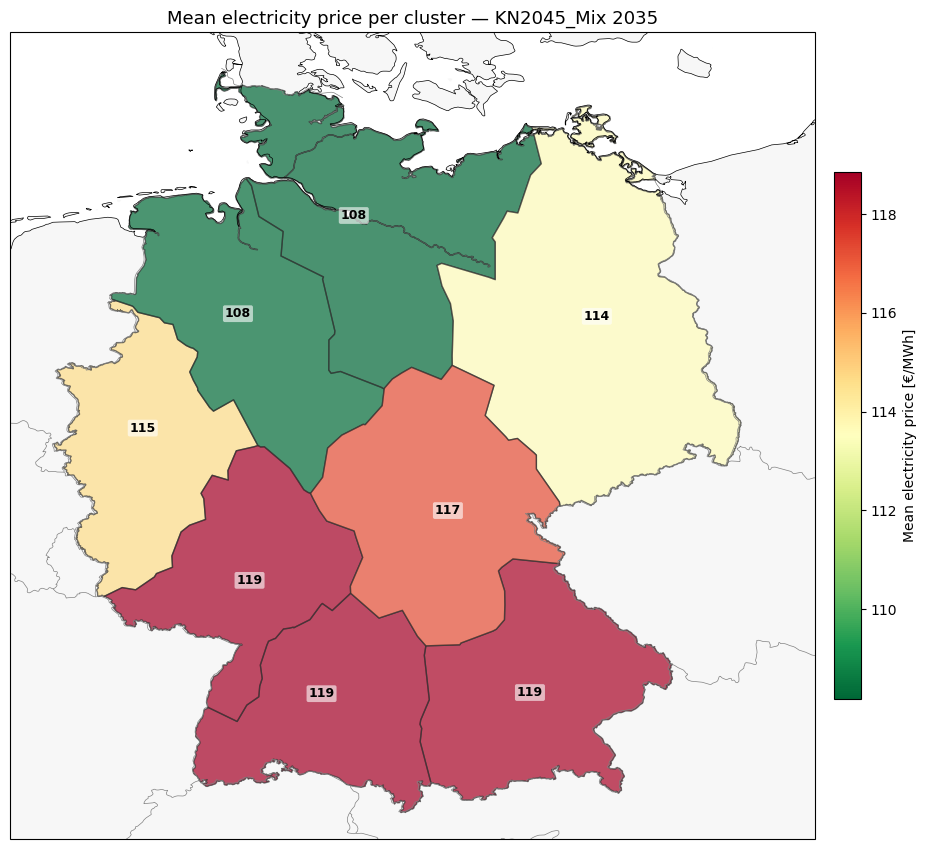


DE load-weighted avg price: 115.0 €/MWh


In [57]:
# Weighted-average marginal price per bus (weighted by snapshot hours)
mean_price = (n.buses_t.marginal_price[de_buses].multiply(sw, axis=0)).sum() / sw.sum()

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

# ── Fill DE cluster zones with price heatmap ──────────────────
norm_p = mcolors.Normalize(vmin=mean_price.min(), vmax=mean_price.max())
cmap_p = plt.cm.RdYlGn_r

for _, row in de_regions.iterrows():
    bus = row["name"]
    val = mean_price.get(bus, mean_price.mean())
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap_p(norm_p(val)),
        edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1,
    )

# Colorbar via ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=norm_p)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label("Mean electricity price [€/MWh]")

# ── Annotate each cluster with its price ──────────────────────
for bus in de_buses:
    bx, by = proj.transform_point(
        ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree()
    )
    ax.annotate(
        f"{mean_price[bus]:.0f}",
        xy=(bx, by), fontsize=9, fontweight="bold",
        ha="center", va="center",
        color="k",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
        zorder=5,
    )

ax.set_title(f"Mean electricity price per cluster — {SCENARIO} {YEAR}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nDE load-weighted avg price: "
      f"{(mean_price * load_per_bus.reindex(de_buses, fill_value=0)).sum() / load_per_bus.sum():.1f} €/MWh")

## 4 — Installed Capacity Pie Chart (Germany)
Pie chart of optimal installed generation & storage capacities in GW.

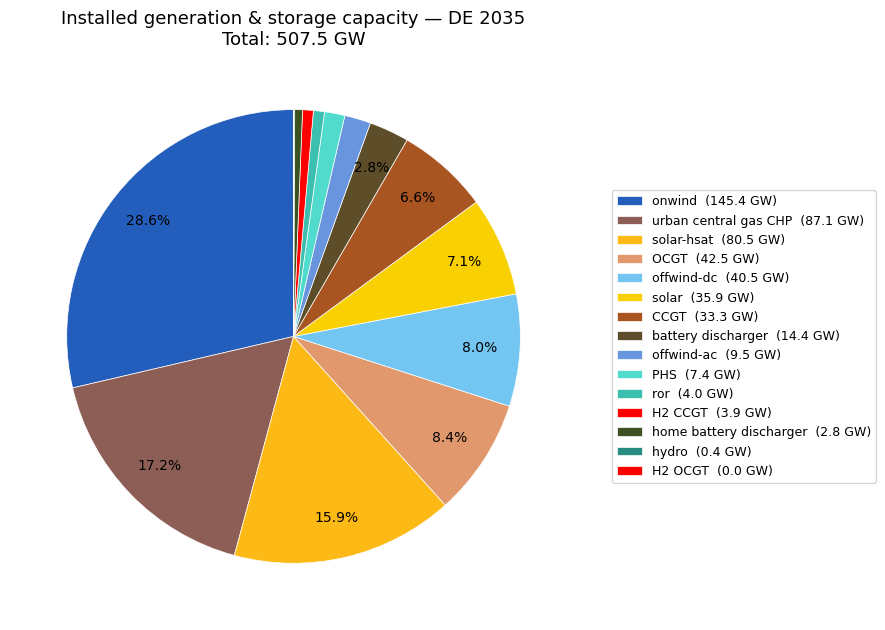

In [45]:
# ── Collect optimal capacities (MW → GW) ──────────────────────
cap = {}

# Generators
g = n.generators[n.generators.bus.isin(de_buses)]
cap_gen = g.groupby("carrier")["p_nom_opt"].sum() / 1e3
cap.update(cap_gen.to_dict())

# Storage units (PHS, hydro)
su = n.storage_units[n.storage_units.bus.isin(de_buses)]
cap_su = su.groupby("carrier")["p_nom_opt"].sum() / 1e3
cap.update(cap_su.to_dict())

# Links acting as generators towards AC buses (battery discharger, H2 Fuel Cell, etc.)
disp_carriers = ["battery discharger", "home battery discharger",
                 "H2 Fuel Cell", "H2 OCGT", "H2 CCGT",
                 "H2 retrofit OCGT", "H2 retrofit CCGT",
                 "urban central gas CHP", "urban central gas CHP CC",
                 "OCGT", "CCGT"]
for c in disp_carriers:
    lk = n.links[(n.links.carrier == c) & (n.links.bus0.isin(de_all_buses) | n.links.bus1.isin(de_all_buses))]
    if not lk.empty:
        cap[c] = lk["p_nom_opt"].sum() / 1e3

cap_s = pd.Series(cap).sort_values(ascending=False)
cap_s = cap_s[cap_s > 0.01]  # drop negligible

# Assign colours
colors = [tech_colors.get(c, "#cccccc") for c in cap_s.index]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    cap_s.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=colors, startangle=90, pctdistance=0.82,
    wedgeprops=dict(edgecolor="w", linewidth=0.5),
)
ax.legend(
    wedges, [f"{c}  ({v:.1f} GW)" for c, v in cap_s.items()],
    loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9,
)
ax.set_title(f"Installed generation & storage capacity — DE {YEAR}\nTotal: {cap_s.sum():.1f} GW", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Generation, Demand & Storage Dispatch
Stacked area plot of electricity generation, demand, and battery charge/discharge.  
Set `T_START` / `T_END` to zoom into a specific period (e.g. a winter week).

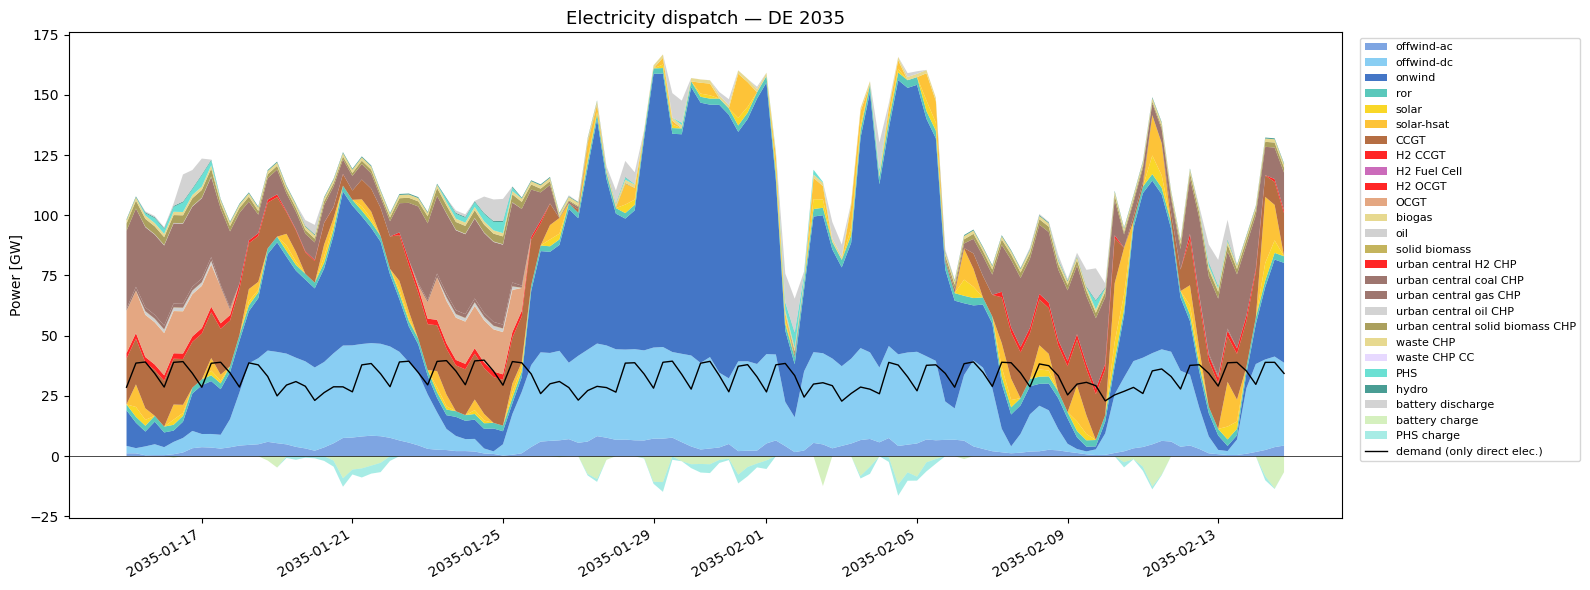

In [65]:
# ── Time window (set to None for full year) ───────────────────
T_START = "2035-01-15"#None   # e.g. "2013-01-15"
T_END   = "2035-02-15"#None   # e.g. "2013-01-29"

ts = n.snapshots
# Shift weather-year timestamps to the model planning horizon for display
year_offset = pd.DateOffset(years=YEAR - ts[0].year)
ts_display = ts + year_offset

if T_START and T_END:
    # Accept dates in either the model year or the weather year
    mask = (ts_display >= T_START) & (ts_display < T_END)
    ts_sel = ts[mask]
    ts_sel_display = ts_display[mask]
else:
    ts_sel = ts
    ts_sel_display = ts_display

# ── Generation by carrier ─────────────────────────────────────
gen_ts = n.generators_t.p[de_gens].loc[ts_sel]
gen_by_carrier = gen_ts.T.groupby(n.generators.loc[de_gens, "carrier"]).sum().T / 1e3  # GW

# Storage-unit dispatch (PHS, hydro)
su_ts = n.storage_units_t.p[de_sus].loc[ts_sel]
su_by_carrier = su_ts.T.groupby(n.storage_units.loc[de_sus, "carrier"]).sum().T / 1e3

# Battery charge / discharge via links
batt_ch_links = n.links[(n.links.carrier == "battery charger") & (n.links.bus0.isin(de_buses))]
batt_dis_links = n.links[(n.links.carrier == "battery discharger") & (n.links.bus1.isin(de_buses))]
batt_charge = n.links_t.p0[batt_ch_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_ch_links) else pd.Series(0, index=ts_sel)
batt_discharge = -n.links_t.p1[batt_dis_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_dis_links) else pd.Series(0, index=ts_sel)

# Link-based dispatchable generation (CHPs, CCGTs, H2 turbines, etc.)
# Uses the same link_gen_links selection from cell 9
disp_gen_ts = -n.links_t.p1[link_gen_links.index].loc[ts_sel]  # −p1 = delivery to AC bus
disp_by_carrier = disp_gen_ts.T.groupby(
    n.links.loc[link_gen_links.index, "carrier"]
).sum().T / 1e3  # GW
# Drop carriers with negligible output
disp_by_carrier = disp_by_carrier.loc[:, disp_by_carrier.sum() > 0.01]

# Total electricity demand
elec_load_ts = n.loads_t.p_set[elec_loads.index].loc[ts_sel].sum(axis=1) / 1e3  # GW

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Stack generation + discharge (positive)
pos_data = gen_by_carrier.copy()
for c in disp_by_carrier.columns:
    pos_data[c] = disp_by_carrier[c]
for c in su_by_carrier.columns:
    pos_data[c] = su_by_carrier[c].clip(lower=0)
pos_data["battery discharge"] = batt_discharge
pos_colors = [tech_colors.get(c, "#cccccc") for c in pos_data.columns]
ax.stackplot(ts_sel_display, pos_data.values.T, labels=pos_data.columns, colors=pos_colors, alpha=0.85)

# Negative: battery charging + pumped-hydro charging
neg = pd.DataFrame(index=ts_sel)
neg["battery charge"] = -batt_charge
for c in su_by_carrier.columns:
    neg_vals = su_by_carrier[c].clip(upper=0)
    if (neg_vals < 0).any():
        neg[c + " charge"] = neg_vals
neg_colors = [tech_colors.get(c.replace(" charge", ""), "#999999") for c in neg.columns]
ax.stackplot(ts_sel_display, neg.values.T, colors=neg_colors, alpha=0.5, labels=neg.columns)

# Demand line
ax.plot(ts_sel_display, elec_load_ts.values, color="k", linewidth=1.0, label="demand (only direct elec.)")

ax.set_ylabel("Power [GW]")
ax.set_title(f"Electricity dispatch — DE {YEAR}", fontsize=13)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, ncol=1)
ax.axhline(0, color="k", linewidth=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6 — Electricity Price Time Series DataFrame
Per-cluster marginal prices and their mean across all DE clusters.

In [59]:
# Build price DataFrame
prices_df = n.buses_t.marginal_price[de_buses].copy()
prices_df.columns = [c.replace(" ", "_") for c in prices_df.columns]
prices_df["DE_mean"] = prices_df.mean(axis=1)

# Basic statistics
print(prices_df.describe().round(1))
prices_df.head(40)

        DE2_0   DE2_1   DE2_2   DE2_3   DE2_4   DE2_5   DE2_6   DE2_7  DE_mean
count  1460.0  1460.0  1460.0  1460.0  1460.0  1460.0  1460.0  1460.0   1460.0
mean    118.7   114.7   108.2   113.6   118.8   108.3   118.8   117.2    114.8
std     110.6   112.7   111.0   111.7   109.5   111.1   110.8   111.5    110.4
min       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0
25%      36.4    25.2    21.7    26.8    37.1    21.5    35.9    33.0     29.5
50%      76.3    70.4    65.2    69.7    80.8    65.5    79.8    73.6     70.6
75%     209.0   211.2   198.7   204.2   207.9   199.1   212.5   208.4    206.2
max     841.0  1116.9   861.8   815.7   894.6   897.3   932.0   854.5    899.9


,DE2_0,DE2_1,DE2_2,DE2_3,DE2_4,DE2_5,DE2_6,DE2_7,DE_mean
snapshot,,,,,,,,,
2013-01-01 00:00:00,63.577723,48.877584,33.882113,25.137525,69.374759,42.529641,61.267776,58.593581,50.405088
2013-01-01 06:00:00,63.577329,57.755240,52.577580,50.236919,69.452663,53.446665,64.167920,58.592546,58.725858
2013-01-01 12:00:00,63.577623,58.918638,52.779395,51.134427,70.396292,53.727041,66.367719,59.608420,59.563694
2013-01-01 18:00:00,63.589697,58.918633,52.779431,56.622588,69.553397,52.479642,66.370446,60.931042,60.155609
2013-01-02 00:00:00,63.591334,58.956756,52.498566,56.555787,69.553921,52.262459,66.651248,60.933218,60.125411
2013-01-02 06:00:00,58.101348,61.649036,52.779634,56.043393,69.226591,53.728043,66.368968,59.604479,59.687686
2013-01-02 12:00:00,63.689770,61.669561,52.779642,55.505675,71.726141,53.733379,67.151208,61.026032,60.910176
2013-01-02 18:00:00,63.706797,57.966300,38.571371,41.431636,77.348714,40.257498,67.150986,54.468639,55.112743
2013-01-03 00:00:00,63.706473,31.767289,0.401911,0.045419,74.231656,0.659330,67.150791,52.806331,36.346150


In [ ]:
# ── Price duration curve + time series ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series
axes[0].plot(prices_df.index, prices_df["DE_mean"], linewidth=0.6, color="#1f77b4")
axes[0].fill_between(
    prices_df.index,
    prices_df.drop(columns="DE_mean").min(axis=1),
    prices_df.drop(columns="DE_mean").max(axis=1),
    alpha=0.2, color="#1f77b4", label="min–max across clusters",
)
axes[0].set_ylabel("Price [€/MWh]")
axes[0].set_title("Electricity price time series (DE mean)")
axes[0].legend(fontsize=8)
fig.autofmt_xdate()

# Duration curve
sorted_prices = np.sort(prices_df["DE_mean"].values)[::-1]
axes[1].plot(range(len(sorted_prices)), sorted_prices, color="#d62728")
axes[1].set_xlabel("Hours (sorted)")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].set_title("Price duration curve")
axes[1].axhline(0, color="k", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

# XX Additional Diagnostics

In [24]:
# ── Electricity-sector bus hierarchy diagnostic ───────────────
# Pick one DE AC bus to trace all connected components
ref_bus = de_buses[0]
ref_loc = ref_bus  # the "location" field on sub-buses points back here

print(f"═══ Reference cluster: {ref_bus} ═══\n")

# 1) Find all buses at this location
cluster_buses = n.buses[n.buses.location == ref_loc].sort_values("carrier")
print("── All buses at this location ──")
for _, b in cluster_buses.iterrows():
    print(f"  {b.name:40s}  carrier: {b.carrier}")

# 2) Lines (AC ↔ AC only)
lines_here = n.lines[(n.lines.bus0 == ref_bus) | (n.lines.bus1 == ref_bus)]
print(f"\n── Lines (AC transmission) ── [{len(lines_here)}]")
for _, ln in lines_here.iterrows():
    other = ln.bus1 if ln.bus0 == ref_bus else ln.bus0
    print(f"  {ref_bus} ↔ {other}  s_nom_opt={ln.s_nom_opt:.0f} MW")

# 3) Generators
gens_here = n.generators[n.generators.bus.isin(cluster_buses.index)]
print(f"\n── Generators ── [{len(gens_here)}]")
for carrier, grp in gens_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 4) Loads
loads_here = n.loads[n.loads.bus.isin(cluster_buses.index)]
print(f"\n── Loads ── [{len(loads_here)}]")
for _, ld in loads_here.iterrows():
    bus_carrier = n.buses.loc[ld.bus, "carrier"]
    print(f"  {ld.carrier:35s} ← {bus_carrier:15s} bus")

# 5) Storage units
sus_here = n.storage_units[n.storage_units.bus.isin(cluster_buses.index)]
print(f"\n── Storage units ── [{len(sus_here)}]")
for carrier, grp in sus_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 6) Stores
stores_here = n.stores[n.stores.bus.isin(cluster_buses.index)]
print(f"\n── Stores ── [{len(stores_here)}]")
for carrier, grp in stores_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   e_nom_opt={grp.e_nom_opt.sum():.0f} MWh")

# 7) Links — the key connectivity layer
links_here = n.links[
    n.links.bus0.isin(cluster_buses.index) |
    n.links.bus1.isin(cluster_buses.index)
]
# Filter to links where at least one end is in the electricity domain
elec_carriers = {"AC", "low voltage", "battery", "home battery", "EV battery"}
elec_links = links_here[
    links_here.bus0.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers) |
    links_here.bus1.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers)
]
print(f"\n── Links (electricity-related) ── [{len(elec_links)}]")
for carrier, grp in elec_links.groupby("carrier"):
    row = grp.iloc[0]
    b0c = n.buses.loc[row.bus0, "carrier"] if row.bus0 in n.buses.index else "?"
    b1c = n.buses.loc[row.bus1, "carrier"] if row.bus1 in n.buses.index else "?"
    # Check for bus2, bus3 (multi-output links like CHP)
    extra = ""
    if hasattr(row, "bus2") and pd.notna(row.get("bus2", None)) and row.bus2 in n.buses.index:
        extra += f" → bus2: {n.buses.loc[row.bus2, 'carrier']}"
    print(f"  {carrier:40s}  {b0c:15s} → {b1c:15s}  p_nom_opt={grp.p_nom_opt.sum():8.0f} MW{extra}")

═══ Reference cluster: DE2 0 ═══

── All buses at this location ──
  DE2 0                                     carrier: AC
  DE2 0 EV battery                          carrier: EV battery
  DE2 0 H2                                  carrier: H2
  DE2 0 agriculture machinery oil           carrier: agriculture machinery oil
  DE2 0 battery                             carrier: battery
  DE2 0 biogas                              carrier: biogas
  DE2 0 co2 sequestered                     carrier: co2 sequestered
  DE2 0 co2 stored                          carrier: co2 stored
  DE2 0 coal for industry                   carrier: coal for industry
  DE2 0 gas for industry                    carrier: gas for industry
  DE2 0 home battery                        carrier: home battery
  DE2 0 kerosene for aviation               carrier: kerosene for aviation
  DE2 0 land transport oil                  carrier: land transport oil
  DE2 0 low voltage                         carrier: low voltage
  DE2